In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000244734""","""mean_corpuscular_haemoglobin_i…",5.8426e-107,-0.414609,0.414609,-1.0
"""ENSG00000188536""","""mean_corpuscular_haemoglobin_i…",4.2593e-22,-0.366514,0.366514,-1.0
"""ENSG00000101439""","""cystatin_c_int""",9.0570e-172,-0.364046,0.364046,-1.0
"""ENSG00000149948""","""standing_height_int""",0.035047,-0.302164,0.302164,-1.0
"""ENSG00000205846""","""aspartate_aminotransferase_int""",0.049103,0.298817,0.298817,1.0
…,…,…,…,…,…
"""ENSG00000104408""","""mean_corpuscular_volume_int""",0.003124,-0.005248,0.005248,-1.0
"""ENSG00000162992""","""glycated_haemoglobin_hba1c_int""",0.000525,0.004895,0.004895,1.0
"""ENSG00000134030""","""leg_fat_percentage_right_int""",0.028495,0.003606,0.003606,1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_local = None
ref_annotation = None
ref_region = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_score""","""pink""","""GPN-MSA""",-1
…,…,…,…,…
"""regulatory_nondir""","""promoterai_abs""","""#80CBC4""","""PromoterAI abs""",1
"""regulatory_nondir""","""abexp_abs_max""","""#b5de2b""","""AbExp abs max""",1
"""regulatory_nondir""","""fz_RNA_all_abs_max""","""#FFA500""","""Flashzoi abs max across RNA al…",1


In [4]:
# new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv40_ukbbgym.parquet"
# !dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

# new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

# new_anno_df = (
#     pl.read_parquet(new_anno_local)
#     .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
#     .with_columns(
#         fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
#         fz_blood_mean = pl.mean_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533']).abs()),
#     )
#     .select(['id', 'region', 'fz_blood_mean', 'fz_all_mean'])
#     .lazy()
# )

# new_anno_df.head().collect()

In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept (with their neutral filled values) instead of being dropped
keep_fillna = False

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True),
        # (pl.any_horizontal(cs.contains("consequence_splice") == True)),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('mobi_curated_disorder_priority') == True),
        # (pl.col('low_complexity_domain') == True),

        # Choose regulatory region
        (pl.col('encode_any_tf') == True),
        # (pl.col('encode_enhancer') == True),
        # (pl.col('encode_promoter') == True),
    
        # Choose pLoF variants
        # (pl.col('loftee_hc') == True),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
    )
)

# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # Gene-Body
# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing'] # missense
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
selected_categories = ['genetic_diversity', 'conservation', 'regulatory_nondir', '3utr'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)


anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_430930/3202744523.py:88: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_430930/3202744523.py:97: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


abexp_abs_max,promoterai_abs,region,id,gpn_score,cadd_raw,aparent2,verphylop
f32,f32,str,str,f32,f32,f32,f32
0.006261,0.0,"""ENSG00000182732""","""chr14:72002332:G:A""",-1.06,0.39212,0.0,0.052
0.006438,0.0,"""ENSG00000107290""","""chr9:132308321:T:C""",-2.26,0.581915,0.0,0.667
0.003333,0.0,"""ENSG00000171150""","""chr2:46767847:C:G""",-1.86,0.3454,0.0,0.265
0.005501,0.0,"""ENSG00000182197""","""chr8:117904832:A:G""",-0.85,0.217674,0.0,-0.178
0.008106,0.0,"""ENSG00000166855""","""chr15:65181479:G:A""",0.88,-0.416695,0.0,-0.231
…,…,…,…,…,…,…,…
0.012463,0.0,"""ENSG00000198604""","""chr14:34833584:T:C""",0.18,1.011178,0.0,1.349
0.007069,0.0,"""ENSG00000135218""","""chr7:80662452:T:C""",-1.3,0.927386,0.0,1.927
0.005262,0.0,"""ENSG00000156802""","""chr8:123350843:G:C""",-1.8,0.157567,0.0,0.484


In [6]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_430930/591762006.py:28: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr6:157703459:C:A""","""ENSG00000130340""","""verphylop""",1
"""chr6:157703252:T:C""","""ENSG00000130340""","""verphylop""",1
"""chr4:2547598:G:T""","""ENSG00000125386""","""verphylop""",1
"""chr2:61387715:T:C""","""ENSG00000115464""","""verphylop""",1
"""chr14:92044416:G:T""","""ENSG00000100815""","""verphylop""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation (skip if keep_fillna=True)
    .pipe(lambda df: df if keep_fillna else df.join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    ))

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_430930/1877447687.py:45: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr19:19238711:T:C""","""ENSG00000130287""","""aparent2""",-0.23999,"""3utr""",1,3774.0
"""chr14:77718024:C:A""","""ENSG00000100603""","""aparent2""",0.10372,"""3utr""",1,592.0
"""chr11:3358495:C:G""","""ENSG00000005801""","""aparent2""",0.02877,"""3utr""",1,1299.0
"""chr11:3358982:A:C""","""ENSG00000005801""","""aparent2""",0.06621,"""3utr""",1,840.0
"""chr7:154861929:C:T""","""ENSG00000130226""","""aparent2""",0.62139,"""3utr""",1,40.0
…,…,…,…,…,…,…
"""chr11:8000651:A:G""","""ENSG00000175390""","""aparent2""",-0.01637,"""3utr""",1,2423.0
"""chr14:73124361:G:A""","""ENSG00000119707""","""aparent2""",-0.2491,"""3utr""",1,3792.0
"""chr19:35050515:A:G""","""ENSG00000105707""","""aparent2""",-0.01748,"""3utr""",1,2442.0


In [8]:
anno['region'].value_counts(sort=True).filter(pl.col('count')>=50)

region,count
str,u64
"""ENSG00000242366""",4064
"""ENSG00000242515""",4010
"""ENSG00000244122""",3874
"""ENSG00000167165""",3874
"""ENSG00000241119""",3874
…,…
"""ENSG00000133895""",52
"""ENSG00000142208""",51
"""ENSG00000188064""",51


In [9]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


## Odds ratio computation

In [10]:
n_steps = 101
min_rank_cutoff = 1_00
max_rank_cutoff = 20_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])

# quant_threshold = 0.99
# zscore_threshold = stats.norm.ppf(quant_threshold) #phenotype percentile threshold to z-score (assuming standard Gaussian)
# print(f"Phenotype threshold: {quant_threshold} → z-score: {zscore_threshold:.4f}")

zscore_threshold = 0.448126   #Obtained from LOFTEE_avg_effect_pheno.ipynb
quant_threshold = stats.norm.cdf(zscore_threshold)
print(f"z-score: {zscore_threshold:.4f} --> Quantile threshold: {quant_threshold:.4f}")

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

# Prepare cutoffs once
cutoffs_sorted = (
    pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})
    .with_columns(pl.col('rank_cutoff').cast(pl.Float32))
    .sort('rank_cutoff')
    .collect()
)

cutoffs_sorted

z-score: 0.4481 --> Quantile threshold: 0.6730


rank_cutoff
f32
100.0
108.0
117.0
126.0
137.0
…
208078.0
225315.0
243981.0


In [11]:
# --- Pre-aggregate per-(region, annotation, rank_cutoff) counts, then bootstrap ---
# We assume mean_pheno_value ~ N(0,1). Extreme = z-score > zscore_threshold.
# Bootstrap across gene-trait pairs to get CIs that account for non-independence.

id_region = anno.select(['id', 'region']).unique().lazy()

# Stream-collect base data ONCE: compute is_extreme using z-score threshold
gp_base = (
    appv
    .join(id_region, on='id', how='inner')
    .join(gene_trait_df.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        is_extreme = (
            pl.when(pl.col('loftee_corr_dir') == -1)
                .then(-pl.col('mean_pheno_value'))
                .otherwise(pl.col('mean_pheno_value'))
            >= zscore_threshold
        )
    )
    .select(['id', 'region', 'is_extreme'])
    .collect(engine='streaming')
)

# --- Step 1: Pre-aggregate per (region, annotation, rank_cutoff) 2x2 table counts ---
all_regions = sorted(gene_trait_df['region'].unique().to_list())
n_regions = len(all_regions)
all_regions_df = pl.DataFrame({'region': all_regions})

annotations_list = sorted(melted_anno['annotation'].unique().to_list())
n_annotations = len(annotations_list)
n_cutoffs = cutoffs_sorted.shape[0]

# 4D array: (n_annotations, n_regions, n_cutoffs, 4)
# 4 = [n_dis_above, n_notdis_above, n_dis_below, n_notdis_below]
counts_4d = np.zeros((n_annotations, n_regions, n_cutoffs, 4), dtype=np.int64)

for a_idx, annotation in enumerate(tqdm(annotations_list, desc='Pre-aggregating')):
    anno_ranks = (
        melted_anno
        .filter(pl.col('annotation') == annotation)
        .select(['id', 'region', 'annotation_score_dircor_rank_desc'])
    )

    # Group by (region, rank), count extreme vs total
    region_rank_counts = (
        gp_base.lazy()
        .join(anno_ranks.lazy(), on=['id', 'region'], how='inner')
        .group_by(['region', 'annotation_score_dircor_rank_desc'])
        .agg(
            n_extreme = pl.col('is_extreme').sum().cast(pl.Int64),
            n_total = pl.len().cast(pl.Int64),
        )
        .collect()
        .sort(['region', 'annotation_score_dircor_rank_desc'])
        .with_columns(
            cum_extreme = pl.col('n_extreme').cum_sum().over('region'),
            cum_total = pl.col('n_total').cum_sum().over('region'),
        )
    )

    # Per-region totals
    region_totals = (
        region_rank_counts
        .group_by('region')
        .agg(
            total_extreme = pl.col('n_extreme').sum(),
            total_count = pl.col('n_total').sum(),
        )
    )

    # Cross join cutoffs × ALL regions, then asof join by region
    per_region = (
        cutoffs_sorted
        .join(all_regions_df, how='cross')
        .sort(['region', 'rank_cutoff'])
        .join_asof(
            region_rank_counts.sort(['region', 'annotation_score_dircor_rank_desc']),
            left_on='rank_cutoff',
            right_on='annotation_score_dircor_rank_desc',
            by='region',
            strategy='backward',
        )
        .with_columns(
            cum_extreme = pl.col('cum_extreme').fill_null(0),
            cum_total = pl.col('cum_total').fill_null(0),
        )
        .join(region_totals, on='region', how='left')
        .with_columns(
            total_extreme = pl.col('total_extreme').fill_null(0),
            total_count = pl.col('total_count').fill_null(0),
        )
        .with_columns(
            n_dis_above = pl.col('cum_extreme'),
            n_notdis_above = pl.col('cum_total') - pl.col('cum_extreme'),
            n_dis_below = pl.col('total_extreme') - pl.col('cum_extreme'),
            n_notdis_below = (pl.col('total_count') - pl.col('total_extreme'))
                           - (pl.col('cum_total') - pl.col('cum_extreme')),
        )
        .sort(['region', 'rank_cutoff'])
    )

    # Vectorized fill: sorted by (region, rank_cutoff), reshape to (n_regions, n_cutoffs)
    # Axis 0: annotation type
    # Axis 1: gene-trait pair (region)
    # Axis 2: quantile cutoff
    # Axis 3: [a, c, b, d] = the four cells of the 2x2 contingency table
    counts_4d[a_idx, :, :, 0] = per_region['n_dis_above'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 1] = per_region['n_notdis_above'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 2] = per_region['n_dis_below'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 3] = per_region['n_notdis_below'].to_numpy().reshape(n_regions, n_cutoffs)

print(f"Pre-aggregated: {counts_4d.shape} = {n_annotations} annos × {n_regions} regions × {n_cutoffs} cutoffs × 4 counts")
print(f"Memory: {counts_4d.nbytes / 1e6:.1f} MB")

# --- Step 2: Point estimate (sum across all regions) ---
total_counts = counts_4d.sum(axis=1)  # (n_annotations, n_cutoffs, 4)
with np.errstate(divide='ignore', invalid='ignore'):
    point_or = (total_counts[:, :, 0] / total_counts[:, :, 1]) / \
               (total_counts[:, :, 2] / total_counts[:, :, 3])

# --- Step 3: Bootstrap CIs across gene-trait pairs ---
n_boot = 1000
rng = np.random.default_rng(42)
boot_ors = np.full((n_boot, n_annotations, n_cutoffs), np.nan)

for b in tqdm(range(n_boot), desc='Bootstrapping'):
    idx = rng.choice(n_regions, size=n_regions, replace=True)
    sampled = counts_4d[:, idx, :, :].sum(axis=1)  # (n_annotations, n_cutoffs, 4)
    with np.errstate(divide='ignore', invalid='ignore'):
        boot_ors[b] = (sampled[:, :, 0] / sampled[:, :, 1]) / (sampled[:, :, 2] / sampled[:, :, 3])

# 95% CIs (percentile method — no log transform needed since percentiles are monotone-invariant)
boot_ci_lower = np.nanpercentile(boot_ors, 2.5, axis=0)
boot_ci_upper = np.nanpercentile(boot_ors, 97.5, axis=0)

# --- Build output DataFrame ---
cutoff_values = cutoffs_sorted['rank_cutoff'].to_numpy()
anno_idx, cutoff_idx = np.meshgrid(np.arange(n_annotations), np.arange(n_cutoffs), indexing='ij')

or_df = (
    pl.DataFrame({
        'annotation': np.array(annotations_list)[anno_idx.ravel()],
        'rank_cutoff': cutoff_values[cutoff_idx.ravel()],
        'n_dis_above': total_counts[:, :, 0].ravel(),
        'n_notdis_above': total_counts[:, :, 1].ravel(),
        'n_dis_below': total_counts[:, :, 2].ravel(),
        'n_notdis_below': total_counts[:, :, 3].ravel(),
        'odds_ratio': point_or.ravel(),
        'ci_lower': boot_ci_lower.ravel(),
        'ci_upper': boot_ci_upper.ravel(),
    })
    .filter(pl.col('odds_ratio').is_finite() & (pl.col('odds_ratio') > 0))
    .sort('rank_cutoff', descending=True)
)

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())
or_df

Pre-aggregating: 100%|██████████| 6/6 [00:00<00:00, 12.01it/s]


Pre-aggregated: (6, 670, 101, 4) = 6 annos × 670 regions × 101 cutoffs × 4 counts
Memory: 13.0 MB


Bootstrapping: 100%|██████████| 1000/1000 [00:02<00:00, 490.43it/s]
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered


unique percentile cutoffs: 99


annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,ci_lower,ci_upper
str,f32,i64,i64,i64,i64,f64,f64,f64
"""cadd_raw""",243981.0,53841,161214,2568,8322,1.082289,1.036118,1.133772
"""gpn_score""",243981.0,54276,161609,2133,7927,1.248131,1.18911,1.314107
"""promoterai_abs""",243981.0,491,1383,55918,168153,1.067609,0.948346,1.18549
"""verphylop""",243981.0,53952,161415,2347,7826,1.114527,1.061105,1.165302
"""abexp_abs_max""",225315.0,49526,148519,2337,6841,0.97614,0.938807,1.0221
…,…,…,…,…,…,…,…,…
"""aparent2""",100.0,23,66,877,2684,1.066515,0.666947,1.662907
"""cadd_raw""",100.0,21,70,56388,169466,0.901607,0.483518,1.459655
"""gpn_score""",100.0,26,61,56383,169475,1.281153,0.86295,1.819004


## Plotting

In [12]:
plt_df = (
    or_df
    .drop_nans()
    .filter(
        pl.col('odds_ratio').is_finite(),
        pl.col('odds_ratio') > 0,
        pl.col('ci_lower') > 0,
        # pl.col('n_dis_above_cutoff')>1,
        # pl.col('n_dis_below_cutoff')>1,
        # pl.col('n_notdis_above_cutoff')>1,
        # pl.col('n_notdis_below_cutoff')>1,
    )

    .with_columns(
        log_rank_cutoff = pl.col('rank_cutoff').log10(),
        log_rank_cutoff_inv = (1 / pl.col('rank_cutoff')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('log_rank_cutoff')
)

plt_df

annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,ci_lower,ci_upper,log_rank_cutoff,log_rank_cutoff_inv,color,label,category
str,f32,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,str
"""abexp_abs_max""",100.0,28,62,51835,155298,1.353035,0.878852,1.895786,2.0,-2.0,"""#b5de2b""","""AbExp abs max""","""regulatory_nondir"""
"""aparent2""",100.0,23,66,877,2684,1.066515,0.666947,1.662907,2.0,-2.0,"""#FFA500""","""Aparent 2""","""3utr"""
"""cadd_raw""",100.0,21,70,56388,169466,0.901607,0.483518,1.459655,2.0,-2.0,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",100.0,26,61,56383,169475,1.281153,0.86295,1.819004,2.0,-2.0,"""pink""","""GPN-MSA""","""conservation"""
"""promoterai_abs""",100.0,17,62,56392,169474,0.82403,0.513069,1.193416,2.0,-2.0,"""#80CBC4""","""PromoterAI abs""","""regulatory_nondir"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""verphylop""",225315.0,50106,149319,6193,19922,1.07946,1.045264,1.112385,5.35279,-5.35279,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""cadd_raw""",243981.0,53841,161214,2568,8322,1.082289,1.036118,1.133772,5.387356,-5.387356,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",243981.0,54276,161609,2133,7927,1.248131,1.18911,1.314107,5.387356,-5.387356,"""pink""","""GPN-MSA""","""conservation"""


In [13]:
import os

loftee_point = [] # Default empty

ref_points_config = [
    # {'annotation': 'loftee_hc', 'variant_filter': 'Gene body'},
    # {'annotation': 'consequence_missense_variant', 'variant_filter': 'Gene body'},
    # {'annotation': 'five_prime_utr_variant_consequence_uframeshift', 'variant_filter': 'Non-CDS'},
    # {'annotation': 'encode_any_tf', 'variant_filter': 'Gene body'},
    # {'annotation': 'encode_enhancer', 'variant_filter': 'Gene body'},
    # {'annotation': 'encode_promoter', 'variant_filter': 'Gene body'},
]

if len(ref_points_config) > 0:
    ref_or_local = f'{LOCAL_APPV_DIR}/category_or_reference_points.tsv'
    RAP_REF_OR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/odds_ratio_results/'

    # 2. Download (remains similar, but cleaner check)
    !dx download {RAP_REF_OR}/category_or_reference_points.tsv -o {ref_or_local} -f 2>/dev/null || echo "Reference file not found"

    if os.path.exists(ref_or_local):
        # Load and Filter using a Join instead of a Loop
        config_df = pl.DataFrame(ref_points_config)
        
        ref_point = (
            pl.read_csv(ref_or_local, separator='\t')
            .join(config_df, on=['annotation', 'variant_filter'])
            # Select the closest pheno_cutoff per annotation
            .sort((pl.col('pheno_cutoff').cast(pl.Float64) - quant_threshold).abs())
            .group_by('annotation').first() 
            .with_columns(
                n_vars = -pl.col('n_variants').cast(pl.Float64).log10(),
                mean_or = pl.col('odds_ratio'),
                ci_low_pheno = pl.col('ci_lower'),
                ci_high_pheno = pl.col('ci_upper')
            )
        )

        if not ref_point.is_empty():
            loftee_point = [
                geom_point(ref_point, aes(x='n_vars', y='mean_or'), color='black', size=2),
                geom_errorbar(ref_point, aes(x='n_vars', y='mean_or', ymin='ci_low_pheno', ymax='ci_high_pheno'), width=0.01, color='black'),
                geom_text(ref_point, aes(x='n_vars', y='mean_or', label='label'), nudge_x=-0.05, size=13, ha='right'),
            ]

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


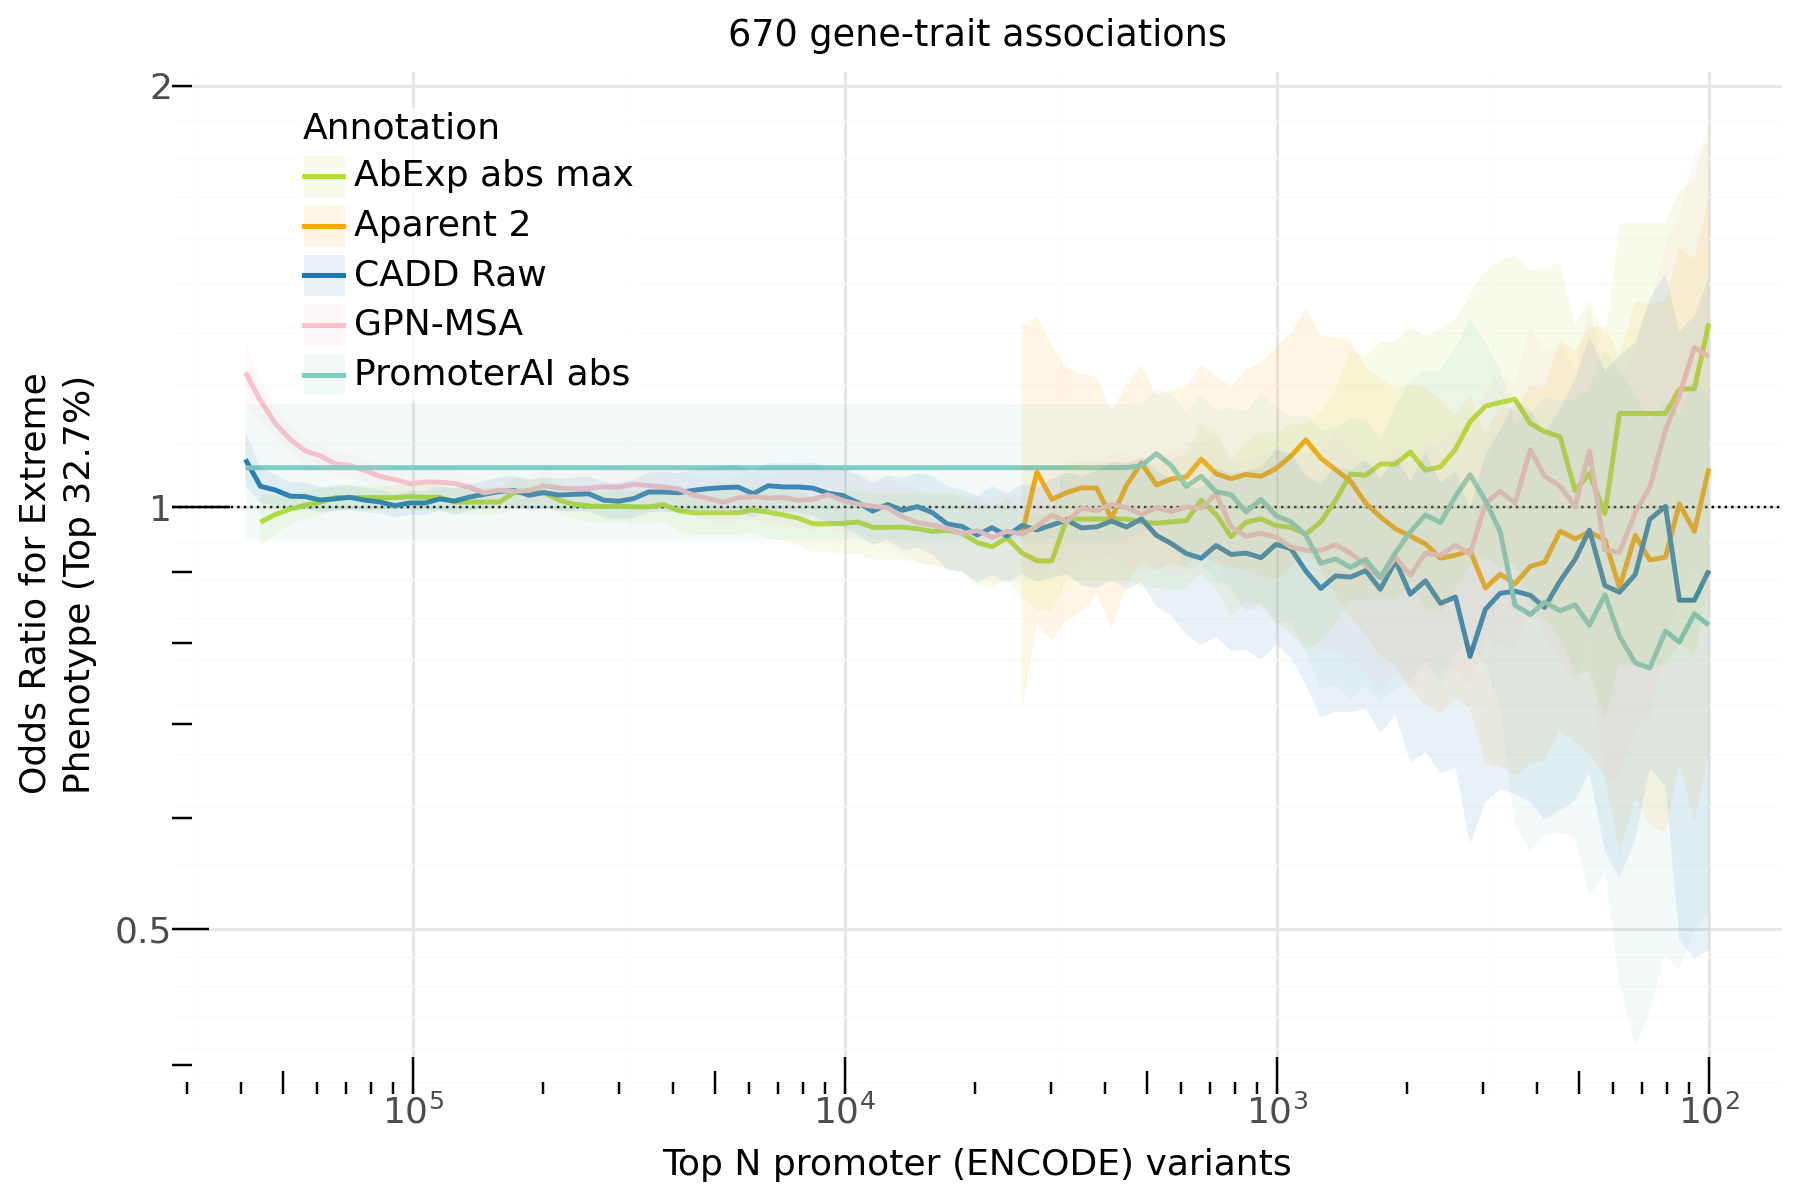

In [14]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') >= -5.5),
        # (pl.col('log_rank_cutoff_inv') <= -3),

        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'gpn_score', 'absplice2_max', 'abexp_abs_max', 'cadd_raw']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'score_pai3d', 'gpn_score', 'verphylop']))
        (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'pangolin_score', 'promoterai_abs', 'abexp_abs_max', 'aparent2']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs', 'fz_RNA_blood_abs_max', 'fz_RNA_all_abs_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs', 'abexp_abs_max']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(-b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - quant_threshold) * 100, 1)

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + loftee_point
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"{gene_trait_df.shape[0]} gene-trait associations",
        y=f"Odds Ratio for Extreme\nPhenotype (Top {pheno_label}%)",
        x=f"Top N promoter (ENCODE) variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.1, 0.95), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)